In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load cleaned NAV history

nav = pd.read_csv(
    "data/processed/cleaned_nav_history.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print("=" * 70)
print("NAV DATA LOADED")
print("=" * 70)

print("Shape:", nav.shape)
print("Number of funds:", nav["amfi_code"].nunique())
print("Date range:", nav["date"].min().date(), "to", nav["date"].max().date())

NAV DATA LOADED
Shape: (46000, 4)
Number of funds: 40
Date range: 2022-01-03 to 2026-05-29


In [3]:
# TASK 1: HISTORICAL VaR AND CVaR
# VaR = 5th percentile of daily returns
# CVaR = mean of returns below VaR threshold

var_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # 95% Historical VaR
    var_95 = np.percentile(returns, 5)

    # CVaR = average of returns worse than VaR
    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append({
        "amfi_code": amfi_code,
        "VaR_95_pct": var_95 * 100,
        "CVaR_95_pct": cvar_95 * 100
    })


var_cvar_df = pd.DataFrame(var_results)

# Add fund information
scheme_info = pd.read_csv(
    "data/processed/cleaned_scheme_performance.csv"
)

var_cvar_df = var_cvar_df.merge(
    scheme_info[
        ["amfi_code", "scheme_name", "fund_house", "risk_grade"]
    ],
    on="amfi_code",
    how="left"
)

# Worst VaR first
var_cvar_df = var_cvar_df.sort_values(
    "VaR_95_pct"
).reset_index(drop=True)

print("=" * 80)
print("HISTORICAL VaR & CVaR — ALL 40 FUNDS")
print("=" * 80)

print(
    var_cvar_df[
        [
            "amfi_code",
            "scheme_name",
            "risk_grade",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ].to_string(index=False)
)

print("\nNumber of funds:", len(var_cvar_df))

HISTORICAL VaR & CVaR — ALL 40 FUNDS
 amfi_code                                           scheme_name      risk_grade  VaR_95_pct  CVaR_95_pct
    119599             SBI Small Cap Fund - Direct Plan - Growth       Very High   -2.685944    -3.238412
    119095                Axis Small Cap Fund - Regular - Growth       Very High   -2.618842    -3.166729
    101207                ABSL Small Cap Fund - Regular - Growth       Very High   -2.602125    -3.245906
    118634        Nippon India Small Cap Fund - Regular - Growth       Very High   -2.543811    -3.230407
    119598            SBI Small Cap Fund - Regular Plan - Growth       Very High   -2.450705    -3.059526
    149324                 DSP Small Cap Fund - Regular - Growth       Very High   -2.348307    -3.103625
    102886                   UTI Mid Cap Fund - Regular - Growth            High   -1.922028    -2.325086
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth            High   -1.903354    -2.345576
    12050

In [4]:
# Save VaR and CVaR report

var_cvar_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "risk_grade",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
].to_csv(
    "var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv saved successfully!")

✅ var_cvar_report.csv saved successfully!


In [5]:
# TASK 2: ROLLING 90-DAY SHARPE RATIO

# Select 5 key funds from the fund scorecard
scorecard = pd.read_csv("fund_scorecard.csv")

top5_codes = scorecard.head(5)["amfi_code"].tolist()

print("Selected 5 funds:")

print(
    scorecard[
        scorecard["amfi_code"].isin(top5_codes)
    ][
        ["amfi_code", "scheme_name", "fund_score"]
    ].to_string(index=False)
)


# Calculate rolling 90-day Sharpe
rolling_sharpe_results = []

for amfi_code in top5_codes:

    fund = nav[
        nav["amfi_code"] == amfi_code
    ].sort_values("date").copy()

    fund["rolling_sharpe_90d"] = (
        fund["daily_return"]
        .rolling(90)
        .mean()
        /
        fund["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe_results.append(
        fund[
            [
                "date",
                "amfi_code",
                "rolling_sharpe_90d"
            ]
        ]
    )


rolling_sharpe_df = pd.concat(
    rolling_sharpe_results,
    ignore_index=True
)

# Add fund names
rolling_sharpe_df = rolling_sharpe_df.merge(
    scorecard[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

print("\nRolling Sharpe calculated successfully!")
print(
    "Observations:",
    len(rolling_sharpe_df)
)

Selected 5 funds:
 amfi_code                                        scheme_name  fund_score
    120505           ICICI Pru Midcap Fund - Regular - Growth       79.62
    120843             Kotak Flexicap Fund - Regular - Growth       78.62
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth       75.88
    119598         SBI Small Cap Fund - Regular Plan - Growth       75.25
    148567      Mirae Asset Large Cap Fund - Regular - Growth       74.62

Rolling Sharpe calculated successfully!
Observations: 5750


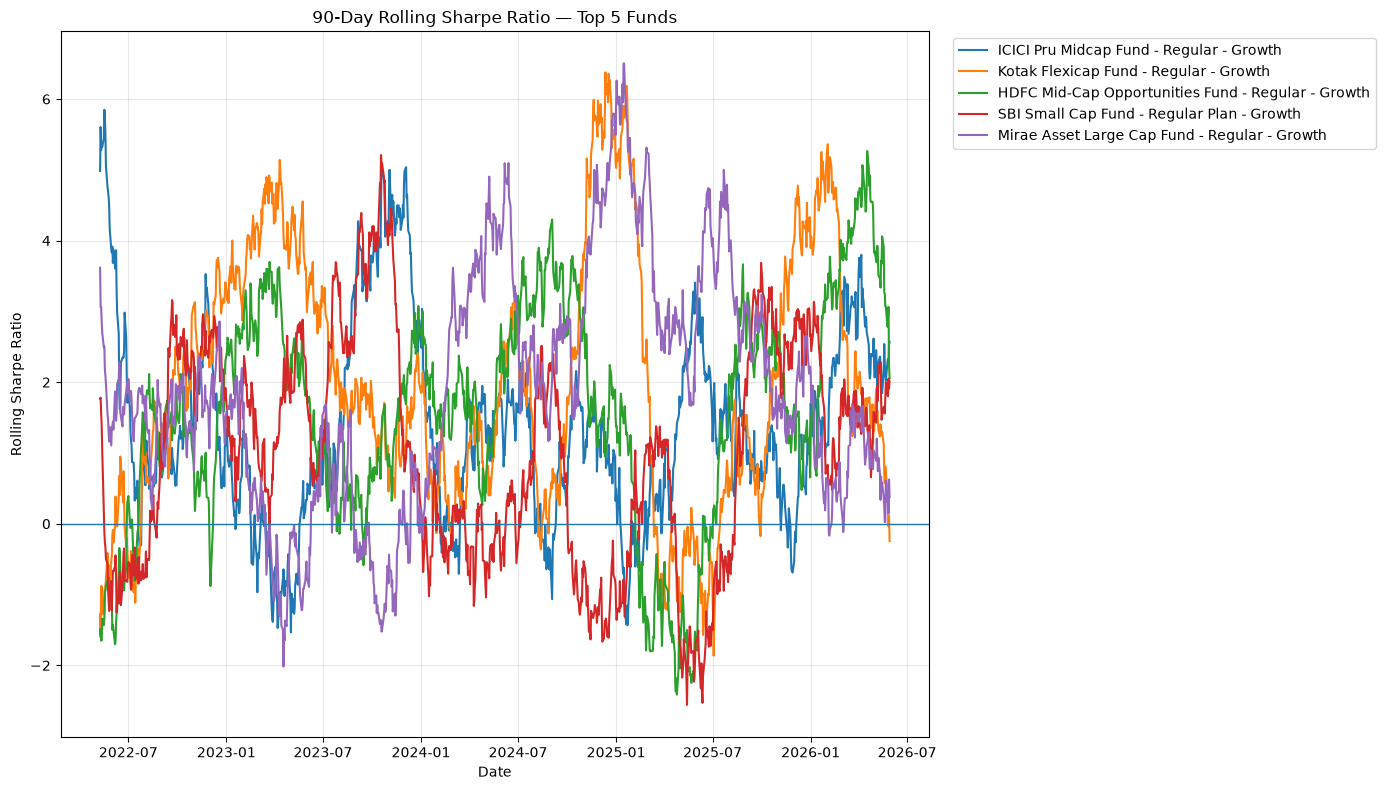

✅ rolling_sharpe_chart.png saved successfully!


In [6]:
# Rolling 90-Day Sharpe Chart

plt.figure(figsize=(14, 8))

for amfi_code in top5_codes:

    fund = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == amfi_code
    ].sort_values("date")

    scheme_name = fund["scheme_name"].iloc[0]

    plt.plot(
        fund["date"],
        fund["rolling_sharpe_90d"],
        label=scheme_name
    )

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio — Top 5 Funds"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ rolling_sharpe_chart.png saved successfully!")

In [7]:
# TASK 3: INVESTOR COHORT ANALYSIS

# Load investor transactions
transactions = pd.read_csv(
    "data/processed/cleaned_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# -------------------------------------------------------
# Find each investor's first transaction
# -------------------------------------------------------

first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

# Add cohort year back to transactions
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

print("=" * 70)
print("INVESTOR COHORT ANALYSIS")
print("=" * 70)

print(
    "Cohort years:",
    sorted(transactions["cohort_year"].unique())
)

INVESTOR COHORT ANALYSIS
Cohort years: [np.int32(2024), np.int32(2025)]


In [8]:
# Calculate cohort metrics

# Total amount invested
total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

# SIP transactions only
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

# Combine metrics
cohort_analysis = total_invested.merge(
    avg_sip,
    on="cohort_year",
    how="left"
)

print("=" * 70)
print("COHORT METRICS")
print("=" * 70)

print(
    cohort_analysis.to_string(index=False)
)

COHORT METRICS
 cohort_year  total_invested_inr  avg_sip_amount_inr
        2024          3491125187        10996.885825
        2025            30455243        13505.209581


In [9]:
# Find top fund preference for each cohort

cohort_fund_counts = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transaction_count")
)

# Get the most preferred fund for each cohort
top_funds = (
    cohort_fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

# Add scheme names
scheme_info = pd.read_csv(
    "data/processed/cleaned_scheme_performance.csv"
)

top_funds = top_funds.merge(
    scheme_info[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_funds = top_funds[
    [
        "cohort_year",
        "amfi_code",
        "scheme_name",
        "transaction_count"
    ]
]

print("=" * 70)
print("TOP FUND PREFERENCE BY COHORT")
print("=" * 70)

print(
    top_funds.to_string(index=False)
)

TOP FUND PREFERENCE BY COHORT
 cohort_year  amfi_code                                           scheme_name  transaction_count
        2024     148568 Mirae Asset Emerging Bluechip Fund - Regular - Growth                874
        2025     119599             SBI Small Cap Fund - Direct Plan - Growth                 12


In [10]:
# Final cohort analysis table

cohort_analysis = cohort_analysis.merge(
    top_funds[
        [
            "cohort_year",
            "scheme_name"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.rename(
    columns={
        "scheme_name": "top_fund_preference"
    }
)

print("=" * 80)
print("FINAL INVESTOR COHORT ANALYSIS")
print("=" * 80)

print(
    cohort_analysis.to_string(index=False)
)

FINAL INVESTOR COHORT ANALYSIS
 cohort_year  total_invested_inr  avg_sip_amount_inr                                   top_fund_preference
        2024          3491125187        10996.885825 Mirae Asset Emerging Bluechip Fund - Regular - Growth
        2025            30455243        13505.209581             SBI Small Cap Fund - Direct Plan - Growth


In [11]:
# TASK 4: SIP CONTINUITY ANALYSIS

# Keep only SIP transactions
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Sort by investor and transaction date
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
).reset_index(drop=True)

# Calculate gap between consecutive SIP transactions
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

print("=" * 70)
print("SIP CONTINUITY ANALYSIS")
print("=" * 70)

print("Total SIP transactions:", len(sip))
print("Unique SIP investors:", sip["investor_id"].nunique())

SIP CONTINUITY ANALYSIS
Total SIP transactions: 19716
Unique SIP investors: 4762


In [12]:
# Identify investors with at least 6 SIP transactions

sip_counts = (
    sip.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

print("=" * 70)
print("ELIGIBLE INVESTORS")
print("=" * 70)

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

ELIGIBLE INVESTORS
Investors with 6+ SIP transactions: 1362


In [13]:
# Calculate average SIP gap for eligible investors

sip_eligible = sip[
    sip["investor_id"].isin(
        eligible_investors["investor_id"]
    )
].copy()

continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transaction_count=(
            "transaction_date",
            "count"
        ),
        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )
    .reset_index()
)

# At-risk if average gap > 35 days
continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

print("=" * 70)
print("SIP CONTINUITY RESULTS")
print("=" * 70)

print(
    continuity.head(20).to_string(index=False)
)

SIP CONTINUITY RESULTS
investor_id  sip_transaction_count  avg_gap_days  status
  INV000004                      6     85.400000 At-Risk
  INV000008                      6     70.400000 At-Risk
  INV000010                      6     64.800000 At-Risk
  INV000011                      7     40.166667 At-Risk
  INV000012                      8     57.000000 At-Risk
  INV000013                      7     55.333333 At-Risk
  INV000014                      7     75.333333 At-Risk
  INV000023                      8     58.571429 At-Risk
  INV000028                      6     93.600000 At-Risk
  INV000029                      7     60.666667 At-Risk
  INV000030                      9     47.625000 At-Risk
  INV000033                      8     45.571429 At-Risk
  INV000039                      6     68.600000 At-Risk
  INV000045                      6     70.600000 At-Risk
  INV000048                      9     46.000000 At-Risk
  INV000052                      6     36.200000 At-Risk
  INV000

In [14]:
# SIP continuity summary

total_eligible = len(continuity)

at_risk_count = (
    continuity["status"] == "At-Risk"
).sum()

regular_count = (
    continuity["status"] == "Regular"
).sum()

at_risk_rate = (
    at_risk_count / total_eligible * 100
    if total_eligible > 0
    else 0
)

print("=" * 70)
print("SIP CONTINUITY SUMMARY")
print("=" * 70)

print("Eligible investors (6+ SIPs):", total_eligible)
print("Regular investors:", regular_count)
print("At-Risk investors:", at_risk_count)
print("At-Risk rate: {:.2f}%".format(at_risk_rate))

SIP CONTINUITY SUMMARY
Eligible investors (6+ SIPs): 1362
Regular investors: 30
At-Risk investors: 1332
At-Risk rate: 97.80%


In [15]:
# TASK 6: CHECK FOR PORTFOLIO HOLDINGS DATA

from pathlib import Path

raw_folder = Path("data/raw")

print("=" * 70)
print("CHECKING AVAILABLE RAW DATASETS")
print("=" * 70)

for file in sorted(raw_folder.glob("*.csv")):
    print(file.name)

CHECKING AVAILABLE RAW DATASETS
01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Axis_Bluechip_NAV.csv
HDFC_Top100_Direct_NAV.csv
ICICI_Bluechip_NAV.csv
Kotak_Bluechip_NAV.csv
Nippon_Large_Cap_NAV.csv
SBI_Bluechip_NAV.csv


In [16]:
# TASK 6: SECTOR HHI CONCENTRATION

holdings = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

print("=" * 70)
print("PORTFOLIO HOLDINGS DATASET")
print("=" * 70)

print("Shape:", holdings.shape)
print("\nColumns:")
print(holdings.columns.tolist())

print("\nFirst 5 rows:")
print(holdings.head())

PORTFOLIO HOLDINGS DATASET
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 rows:
   amfi_code stock_symbol                stock_name       sector  weight_pct  market_value_cr  current_price_inr portfolio_date
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85           737.09            6011.08     2025-12-31
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19            88.97            1074.65     2025-12-31
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90           208.45            5964.59     2025-12-31
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76           161.32            3748.82     2025-12-31
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25           725.90            1321.45     2025-12-31


In [17]:
# TASK 6: SECTOR HHI CONCENTRATION

holdings["weight"] = holdings["weight_pct"] / 100

# First aggregate stock weights by sector for each fund
sector_weights = (
    holdings
    .groupby(
        ["amfi_code", "sector"],
        as_index=False
    )["weight"]
    .sum()
)

# Calculate HHI = sum(weight_i^2)
hhi_df = (
    sector_weights
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="sector_hhi")
)

# Add fund information
hhi_df = hhi_df.merge(
    scheme_info[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

# Keep equity-oriented funds
equity_hhi = hhi_df[
    hhi_df["category"].str.contains(
        "Equity|Large Cap|Mid Cap|Small Cap|Flexi Cap",
        case=False,
        na=False
    )
].copy()

# Highest HHI = most concentrated
equity_hhi = equity_hhi.sort_values(
    "sector_hhi",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("SECTOR HHI — EQUITY FUNDS")
print("=" * 80)

print(
    equity_hhi[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "sector_hhi"
        ]
    ].to_string(index=False)
)

print("\nHighest HHI = more concentrated")
print("Lower HHI = more diversified")

SECTOR HHI — EQUITY FUNDS
 amfi_code                                           scheme_name        category  sector_hhi
    119092                 Axis Bluechip Fund - Regular - Growth       Large Cap    0.296769
    125498     HDFC Mid-Cap Opportunities Fund - Direct - Growth         Mid Cap    0.253155
    102887                 UTI Flexi Cap Fund - Regular - Growth       Flexi Cap    0.251383
    149323                    DSP Midcap Fund - Regular - Growth         Mid Cap    0.241077
    120505              ICICI Pru Midcap Fund - Regular - Growth         Mid Cap    0.238695
    119599             SBI Small Cap Fund - Direct Plan - Growth       Small Cap    0.232361
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth         Mid Cap    0.227647
    119552              SBI Bluechip Fund - Direct Plan - Growth       Large Cap    0.227508
    101207                ABSL Small Cap Fund - Regular - Growth       Small Cap    0.222727
    120504             ICICI Pru Bluechip Fu

In [18]:
# Save HHI analysis

equity_hhi.to_csv(
    "sector_hhi_report.csv",
    index=False
)

print("✅ sector_hhi_report.csv saved successfully!")

✅ sector_hhi_report.csv saved successfully!


# Advanced Analytics — Key Insights

## 1. VaR and CVaR Risk

The Historical 95% VaR and CVaR analysis identifies the funds with the
largest downside exposure. VaR represents the 5th percentile of daily
returns, while CVaR represents the average return during the worst 5%
of trading days. Funds with more negative VaR and CVaR values have
greater downside risk.

## 2. Risk-Adjusted Performance

The 90-day rolling Sharpe Ratio shows how risk-adjusted performance
changes over time for the selected key funds. Positive Sharpe values
indicate that returns have compensated investors for the volatility
during the corresponding rolling period, while negative values indicate
weak risk-adjusted performance.

## 3. Investor Cohort Behaviour

Investor cohort analysis groups investors according to the year of
their first transaction. Comparing total invested amounts and average
SIP amounts across cohorts helps identify changes in investor
participation and investment behaviour over time. The analysis also
identifies the most frequently transacted fund for each cohort.

## 4. SIP Continuity and At-Risk Investors

Investors with at least six SIP transactions were evaluated based on
the average gap between consecutive SIP dates. Investors with an
average gap greater than 35 days were classified as "At-Risk". This
metric can help identify investors whose SIP investment behaviour may
be becoming irregular.

## 5. Sector Concentration

Sector HHI measures how concentrated each equity fund's portfolio is
across sectors. A higher HHI indicates greater concentration in fewer
sectors, while a lower HHI indicates greater sector diversification.
This metric can be used alongside return and risk measures when
evaluating portfolio diversification.